# Predicciones de clasificación de imágenes

Este notebook demuestra el uso de un modelo previamente entrenado (`modelo_CNN_Aug.keras`) para realizar **predicciones de clasificación de imágenes** del juego "Piedra, Papel o Tijera". Además, se evalúa el desempeño del modelo con una **matriz de confusión**.

Las principales actividades incluyen:

- Carga del modelo entrenado con aumento de datos.
- Visualización de imágenes de prueba de cada clase.
- Preprocesamiento de imágenes nuevas (redimensionamiento, normalización y reformateo).
- Predicción de la clase correspondiente para cada imagen usando el modelo.
- Evaluación del modelo con los datos de prueba originales.
- Visualización de la **matriz de confusión** para analizar el rendimiento del modelo por clase.

>  Esta etapa representa la validación final del modelo en condiciones reales de uso, comprobando su capacidad de generalización y precisión.


In [ ]:
# Load google drive to google colab
from google.colab import drive
drive.mount('/content/MyDrive')

Drive already mounted at /content/MyDrive; to attempt to forcibly remount, call drive.mount("/content/MyDrive", force_remount=True).


In [ ]:
import os
#os.chdir('DIRECTORIO LOCAL')
os.chdir('DIRECTORIO')


In [ ]:
!ls test

gato_ejemplo.jpg  papel.jpg  piedra.jpg  tijera.jpg


In [ ]:
from keras.models import load_model
import h5py

In [ ]:
model = load_model('---MODELO--')

In [ ]:
from tensorflow.keras.utils import  array_to_img, img_to_array, load_img

In [ ]:
!ls  dataset_test

papel  piedra  tijera  X_hand_test.npy	y_hand_test.npy


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2 as cv
from numpy import random
import glob
from numpy import load

import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 535ms/step


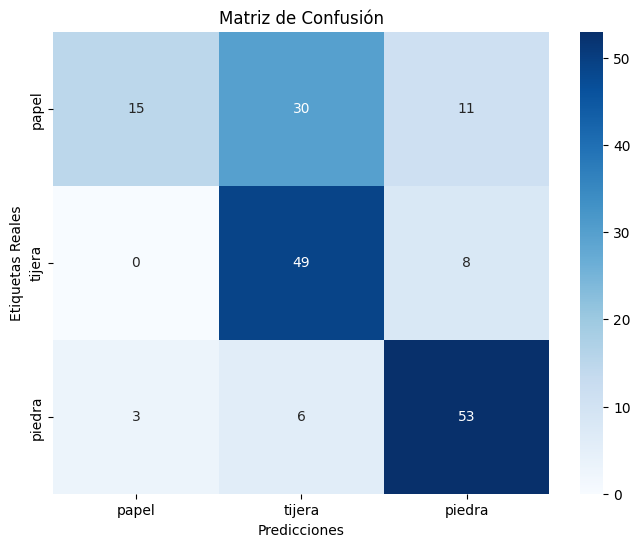

In [ ]:
# Cargar los datos
X_test = np.load('dataset_test/X_hand_test.npy')
y_test = np.load('dataset_test/y_hand_test.npy')


##
import tensorflow as tf
X_test= tf.image.resize(X_test, (75, 75))

# Escalar los datos
X_test_scaled = X_test / 255

#  Predicciones sobre los datos de test
y_pred = model.predict(X_test_scaled)

# Convertir las predicciones (one-hot) a etiquetas de clase
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = y_test # Assuming y_test_oct is already in class labels

# Convertir los índices a las etiquetas correspondientes usando el diccionario
labels_dict = {'papel': 0, 'tijera': 1, 'piedra': 2}
labels = list(labels_dict.keys())

#  Calcular la matriz de confusión
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas Reales')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Encontrar índices de ejemplos mal clasificados
misclassified_indices = np.where(y_pred_classes_oct != y_true_classes_oct)[0]

# Seleccionar aleatoriamente algunos índices mal clasificados
num_ejemplos = min(9, len(misclassified_indices))  # Mostrar hasta 9
random_misclassified_indices = np.random.choice(misclassified_indices, size=num_ejemplos, replace=False)


plt.figure(figsize=(12, 10))

for i, idx in enumerate(random_misclassified_indices):
    img = X_test_oct[idx].astype("uint8")  # Imagen original sin escalar
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir a RGB
    true_label = labels[y_true_classes_oct[idx]]
    pred_label = labels[y_pred_classes_oct[idx]]

    plt.subplot(3, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(f'Real: {true_label} / Pred: {pred_label}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Encontrar índices de ejemplos bien clasificados
correctly_classified_indices = np.where(y_pred_classes_oct == y_true_classes_oct)[0]

# Seleccionar aleatoriamente algunos índices bien clasificados
num_ejemplos_correctos = min(9, len(correctly_classified_indices))  # Mostrar hasta 9
random_correctly_classified_indices = np.random.choice(correctly_classified_indices, size=num_ejemplos_correctos, replace=False)

plt.figure(figsize=(12, 10))

for i, idx in enumerate(random_correctly_classified_indices):
    img = X_test_oct[idx].astype("uint8")  # Imagen original sin escalar
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir a RGB
    true_label = labels[y_true_classes_oct[idx]]
    pred_label = labels[y_pred_classes_oct[idx]]

    plt.subplot(3, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(f'Real: {true_label} / Pred: {pred_label}')
    plt.axis('off')

plt.tight_layout()
plt.show()